In [ ]:
!wget https://d3s0tskafalll9.cloudfront.net/media/images/E-8-6.max-800x600_rkMHa4K.png # 기본 제공 이미지입니다. 여러분만의 이미지로 수정해보세요!
!mv E-8-6.max-800x600_rkMHa4K.png ~/work/camera_sticker/images/image.png

In [1]:
# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 카메라 스티커 앱을 위한 필요한 디렉토리 생성
!mkdir -p ~/work/camera_sticker/images
!mkdir -p ~/work/camera_sticker/sticker

# Google Drive에서 얼굴 이미지를 images 디렉토리로 복사하고 image.png로 이름 변경
# 'G:\내 드라이브'는 Colab에서 일반적으로 '/content/drive/MyDrive'로 매핑됩니다.
!cp '/content/drive/MyDrive/Colab Notebooks/CV_01_Main_Quest/model/20260420_112806.jpg' ~/work/camera_sticker/images/image.png

# Google Drive에서 스티커 이미지를 sticker 디렉토리로 복사
!cp '/content/drive/MyDrive/Colab Notebooks/CV_01_Main_Quest/sticker/cat-whiskers.png' ~/work/camera_sticker/sticker/cat-whiskers.png

In [5]:
!pip install cmake # CMake 설치
!pip install opencv-python # OpenCV Python 라이브러리 설치
!pip install dlib # dlib 라이브러리 설치

In [6]:
# 필요한 패키지 import 하기
import os # 환경 변수나 디렉터리, 파일 등의 OS 자원을 제어할 수 있게 해주는 모듈
import cv2 # OpenCV라이브러리 → 컴퓨터 비전 관련 프로그래밍을 쉽게 할 수 있도록 도와주는 라이브러리
import matplotlib.pyplot as plt # 다양한 데이터를 많은 방법으로 도식화 할 수 있도록 하는 라이브러리
import numpy as np # 다차원 배열을 쉽게 처리하고 효율적으로 사용할 수 있도록 하는 라이브러리
import dlib # 이미지 처리 및 기계 학습, 얼굴인식 등을 할 수 있는 c++ 로 개발된 고성능의 라이브러리
print("🌫🛸")

🌫🛸


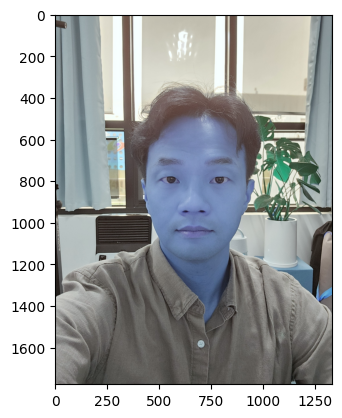

In [7]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/camera_sticker/images/image.png') # 본인 이미지가 있는 경로를 가지고 온다.
img_bgr = cv2.imread(my_image_path)    # OpenCV로 이미지를 불러옵니다
img_show = img_bgr.copy()      # 출력용 이미지를 따로 보관합니다
plt.imshow(img_bgr) # 이미지를 출력하기 위해 출력할 이미지를 올려준다. (실제 출력은 하지 않음)
plt.show() # 이미지를 출력해준다. (실제 출력)

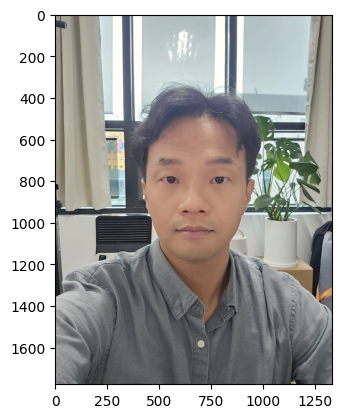

In [11]:
# plt.imshow 이전에 RGB 이미지로 바꾸는 것을 잊지마세요.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

In [12]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환
print("🌫🛸")

🌫🛸


In [13]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)
print("🌫🛸")

🌫🛸


rectangles[[(451, 657) (913, 1119)]]


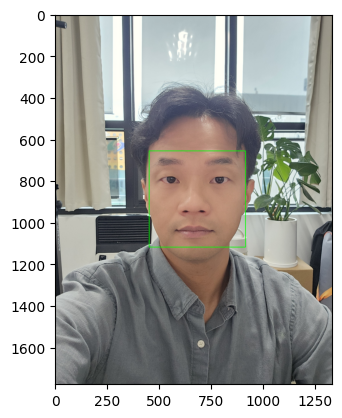

In [14]:
# 찾은 얼굴 영역 박스 리스트
# 여러 얼굴이 있을 수 있습니다
print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

In [15]:
# 모델 저장 디렉토리 생성
!mkdir -p ~/work/camera_sticker/models

In [16]:
# dlib 얼굴 랜드마크 예측 모델 다운로드
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2

--2026-04-20 02:50:15--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-04-20 02:50:15--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  39.4MB/s    in 1.6s    

2026-04-20 02:50:17 (39.4 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



In [17]:
# 다운로드한 모델 파일 이동
!mv shape_predictor_68_face_landmarks.dat.bz2 ~/work/camera_sticker/models

In [18]:
# 모델 파일 압축 해제
!cd ~/work/camera_sticker && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

In [19]:
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
    # 저장한 landmark 모델의 주소를 model_path 변수에 저장
landmark_predictor = dlib.shape_predictor(model_path)
    # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
    # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
    # dlib.rectangle: 내부를 예측하는 박스
    # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄
print("🌫🛸")

🌫🛸


In [20]:
list_landmarks = []
    # 랜드마크의 위치를 저장할 list 생성

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장

print(len(list_landmarks[0]))
    # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
    # 각 원소는 68개의 랜드마크 위치가 나열된 list
    # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

68


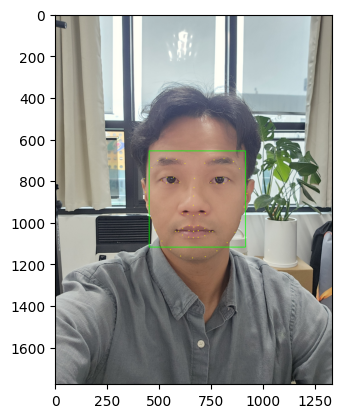

In [21]:
# list_landmarks의 원소가 1개이므로 아래 반복문은 한번만 실행됨
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)
            # cv2.circle: OpenCV의 원을 그리는 함수
            # img_show 이미지 위 각각의 point에
            # 크기가 2이고 (0, 255, 255)색으로 내부가 채워진(-1) 원을 그림
            # (마지막 인수가 자연수라면 그만큼의 두께의 선으로 원이 그려짐)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    # RGB 이미지로 전환
plt.imshow(img_show_rgb)
    # 이미지를 준비
plt.show()
    # 이미지를 출력

### 🐱 고양이 수염 스티커 적용

이제 준비된 고양이 수염 스티커 이미지를 얼굴 랜드마크 위치에 맞춰 적용해 보겠습니다.

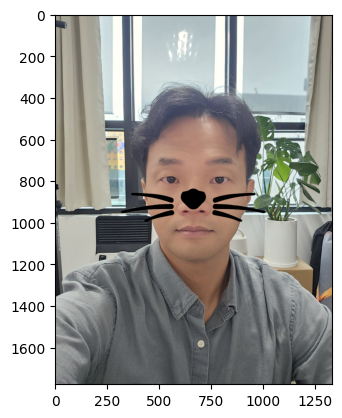

In [22]:
import os # 환경 변수나 디렉터리, 파일 등의 OS 자원을 제어할 수 있게 해주는 모듈
import cv2 # OpenCV라이브러리 → 컴퓨터 비전 관련 프로그래밍을 쉽게 할 수 있도록 도와주는 라이브러리
import matplotlib.pyplot as plt # 다양한 데이터를 많은 방법으로 도식화 할 수 있도록 하는 라이브러리
import numpy as np # 다차원 배열을 쉽게 처리하고 효율적으로 사용할 수 있도록 하는 라이브러리
import dlib # 이미지 처리 및 기계 학습, 얼굴인식 등을 할 수 있는 c++ 로 개발된 고성능의 라이브러리

# 스티커 이미지 경로 설정 및 불러오기 (투명도 채널 포함)
sticker_path = os.path.join(home_dir, 'work/camera_sticker/sticker/cat-whiskers.png')
img_sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)

# 원본 이미지를 복사하여 스티커를 붙일 이미지 준비
# (이전에 랜드마크가 그려진 img_show 대신 깨끗한 원본 img_bgr 사용)
img_result = img_bgr.copy()

for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    # 고양이 수염 스티커를 붙일 위치를 코 랜드마크(index 30)와 인중 랜드마크(index 33)를 기준으로 계산합니다.
    # 코 랜드마크의 x, y 좌표
    x_nose = landmark[30][0]
    y_nose_tip = landmark[30][1] # 코 끝 (landmark 30)
    y_philtrum = landmark[33][1] # 인중 (landmark 33, 코 바로 아래)

    # 스티커의 크기를 얼굴 영역의 너비를 기준으로 설정합니다.
    w_face = dlib_rect.width()
    h_face = dlib_rect.height()

    # 스티커의 비율을 유지하면서 얼굴 너비에 맞게 크기 조정
    # 스티커 이미지의 원래 높이와 너비
    sticker_h_original, sticker_w_original, _ = img_sticker.shape

    # 얼굴 너비에 비례하여 스티커 너비 설정 (예: 얼굴 너비의 2.0배 정도로 조절)
    # 수염은 얼굴보다 약간 넓게 퍼지는 경향이 있으므로 2.0배로 설정 (사용자 요청에 따라 1.5 -> 2.0 조정)
    sticker_w_new = int(w_face * 2.0)

    # 새로운 높이 계산 (비율 유지)
    sticker_h_new = int(sticker_h_original * (sticker_w_new / sticker_w_original))

    # 스티커 이미지 크기 조정
    img_sticker_resized = cv2.resize(img_sticker, (sticker_w_new, sticker_h_new), interpolation=cv2.INTER_AREA)

    # 스티커를 적용할 영역 (ROI) 좌표 계산
    # 스티커의 중심을 코 랜드마크 x 좌표에 맞춥니다.
    sticker_x = x_nose - sticker_w_new // 2

    # 스티커의 수직 중심을 코 끝(landmark 30)과 인중(landmark 33)의 중간에 위치시킵니다.
    y_target_center = (y_nose_tip + y_philtrum) // 2
    sticker_y = y_target_center - sticker_h_new // 2

    # 이미지 경계를 벗어나지 않도록 스티커 위치 및 크기 조정
    # 스티커가 이미지 영역 밖으로 나가는 경우 잘라내야 함

    # 스티커의 좌상단 좌표
    x1 = sticker_x
    y1 = sticker_y
    # 스티커의 우하단 좌표
    x2 = sticker_x + sticker_w_new
    y2 = sticker_y + sticker_h_new

    # 이미지의 너비와 높이
    img_h, img_w, _ = img_result.shape

    # 스티커가 이미지 경계를 벗어나는 경우 처리
    # 스티커 자체를 잘라내고, ROI 시작점 조정

    # 잘라낼 스티커의 좌상단 좌표 (sticker_crop_x1, sticker_crop_y1)
    # 이미지 내 ROI의 좌상단 좌표 (roi_x1, roi_y1)

    sticker_crop_x1 = 0
    sticker_crop_y1 = 0
    roi_x1 = x1
    roi_y1 = y1

    if x1 < 0:
        sticker_crop_x1 = -x1
        roi_x1 = 0
    if y1 < 0:
        sticker_crop_y1 = -y1
        roi_y1 = 0

    sticker_crop_x2 = sticker_w_new
    sticker_crop_y2 = sticker_h_new
    roi_x2 = x2
    roi_y2 = y2

    if x2 > img_w:
        sticker_crop_x2 = sticker_w_new - (x2 - img_w)
        roi_x2 = img_w
    if y2 > img_h:
        sticker_crop_y2 = sticker_h_new - (y2 - img_h)
        roi_y2 = img_h

    # 최종 스티커 크기 및 ROI 계산
    img_sticker_cropped = img_sticker_resized[sticker_crop_y1:sticker_crop_y2, sticker_crop_x1:sticker_crop_x2]
    roi = img_result[roi_y1:roi_y2, roi_x1:roi_x2]

    # 스티커가 이미지 경계 밖으로 완전히 나가는 경우 스킵
    if img_sticker_cropped.shape[0] <= 0 or img_sticker_cropped.shape[1] <= 0:
        continue

    # 스티커에 투명도가 있는 경우 처리 (알파 채널 이용)
    alpha_s = img_sticker_cropped[:, :, 3] / 255.0
    alpha_l = 1.0 - alpha_s

    for c in range(0, 3):
        roi[:, :, c] = (alpha_s * img_sticker_cropped[:, :, c] +
                        alpha_l * roi[:, :, c])

# 결과 이미지 시각화
img_result_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)
plt.imshow(img_result_rgb)
plt.show()

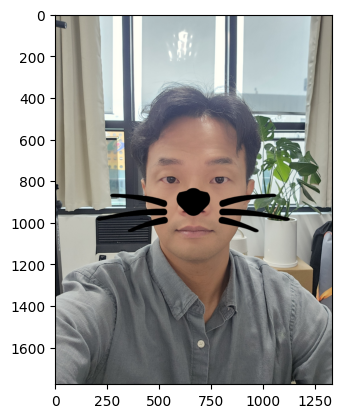

In [28]:
# 원본 이미지를 복사하여 스티커를 붙일 이미지 준비 (새로운 코드)
img_result_new = img_bgr.copy()

for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    # 고양이 수염 스티커를 붙일 위치를 코 랜드마크(index 30)와 인중 랜드마크(index 33)를 기준으로 계산합니다.
    # 코 랜드마크의 x, y 좌표
    x_nose = landmark[30][0]
    y_nose_tip = landmark[30][1] # 코 끝 (landmark 30)
    y_philtrum = landmark[33][1] # 인중 (landmark 33, 코 바로 아래)

    # 스티커의 크기를 얼굴 영역의 너비를 기준으로 설정합니다.
    w_face = dlib_rect.width()
    # 스티커의 비율을 유지하면서 얼굴 너비에 맞게 크기 조정
    sticker_h_original, sticker_w_original, _ = img_sticker.shape

    # 얼굴 너비에 비례하여 스티커 너비 설정 (예: 얼굴 너비의 2.0배 정도로 조절)
    # 사용자 요청에 따라 1.5 -> 2.0으로 조정
    sticker_w_new = int(w_face * 2.0)

    # 새로운 높이 계산 (비율 유지)
    sticker_h_new = int(sticker_h_original * (sticker_w_new / sticker_w_original))

    # 스티커 이미지 크기 조정
    img_sticker_resized = cv2.resize(img_sticker, (sticker_w_new, sticker_h_new), interpolation=cv2.INTER_AREA)

    # 스티커를 적용할 영역 (ROI) 좌표 계산
    # 스티커의 중심을 코 랜드마크 x 좌표에 맞춥니다.
    sticker_x = x_nose - sticker_w_new // 2

    # 스티커의 수직 중심을 코 끝(landmark 30)과 인중(landmark 33)의 중간에 위치시킵니다.
    y_target_center = (y_nose_tip + y_philtrum) // 2
    sticker_y = y_target_center - sticker_h_new // 2

    # 이미지 경계를 벗어나지 않도록 스티커 위치 및 크기 조정
    # 스티커가 이미지 영역 밖으로 나가는 경우 잘라내야 함

    # 스티커의 좌상단 좌표
    x1 = sticker_x
    y1 = sticker_y
    # 스티커의 우하단 좌표
    x2 = sticker_x + sticker_w_new
    y2 = sticker_y + sticker_h_new

    # 이미지의 너비와 높이
    img_h, img_w, _ = img_result_new.shape

    # 스티커가 이미지 경계를 벗어나는 경우 처리
    # 스티커 자체를 잘라내고, ROI 시작점 조정

    sticker_crop_x1 = 0
    sticker_crop_y1 = 0
    roi_x1 = x1
    roi_y1 = y1

    if x1 < 0:
        sticker_crop_x1 = -x1
        roi_x1 = 0
    if y1 < 0:
        sticker_crop_y1 = -y1
        roi_y1 = 0

    sticker_crop_x2 = sticker_w_new
    sticker_crop_y2 = sticker_h_new
    roi_x2 = x2
    roi_y2 = y2

    if x2 > img_w:
        sticker_crop_x2 = sticker_w_new - (x2 - img_w)
        roi_x2 = img_w
    if y2 > img_h:
        sticker_crop_y2 = sticker_h_new - (y2 - img_h)
        roi_y2 = img_h

    # 최종 스티커 크기 및 ROI 계산
    img_sticker_cropped = img_sticker_resized[sticker_crop_y1:sticker_crop_y2, sticker_crop_x1:sticker_crop_x2]
    roi = img_result_new[roi_y1:roi_y2, roi_x1:roi_x2]

    # 스티커가 이미지 경계 밖으로 완전히 나가는 경우 스킵
    if img_sticker_cropped.shape[0] <= 0 or img_sticker_cropped.shape[1] <= 0:
        continue

    # 스티커에 투명도가 있는 경우 처리 (알파 채널 이용)
    alpha_s = img_sticker_cropped[:, :, 3] / 255.0
    alpha_l = 1.0 - alpha_s

    for c in range(0, 3):
        roi[:, :, c] = (alpha_s * img_sticker_cropped[:, :, c] +
                        alpha_l * roi[:, :, c])

# 결과 이미지 시각화 (새로운 결과 이미지를 사용합니다)
img_result_new_rgb = cv2.cvtColor(img_result_new, cv2.COLOR_BGR2RGB)
plt.imshow(img_result_new_rgb)
plt.show()

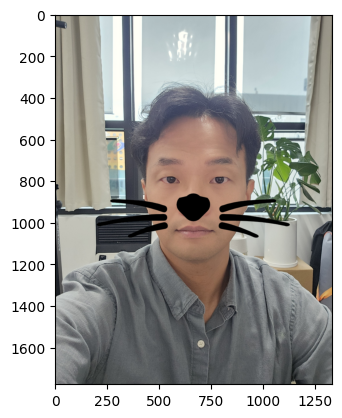

In [32]:
img_result_adjusted = img_bgr.copy()

# 미세 조정을 위한 y축 오프셋을 정의합니다.
y_offset_fine_tune = 50 # 스티커를 50픽셀 더 아래로 이동

for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    x_nose = landmark[30][0]
    y_nose_tip = landmark[30][1]
    y_philtrum = landmark[33][1]

    w_face = dlib_rect.width()

    sticker_h_original, sticker_w_original, _ = img_sticker.shape

    sticker_w_new = int(w_face * 2.0)
    sticker_h_new = int(sticker_h_original * (sticker_w_new / sticker_w_original))

    img_sticker_resized = cv2.resize(img_sticker, (sticker_w_new, sticker_h_new), interpolation=cv2.INTER_AREA)

    sticker_x = x_nose - sticker_w_new // 2

    # 스티커의 중심을 코 끝(landmark 30)에 맞추고 미세 조정을 위한 오프셋을 적용합니다.
    sticker_y = y_nose_tip - sticker_h_new // 2 + y_offset_fine_tune

    x1 = sticker_x
    y1 = sticker_y
    x2 = sticker_x + sticker_w_new
    y2 = sticker_y + sticker_h_new

    img_h, img_w, _ = img_result_adjusted.shape

    sticker_crop_x1 = 0
    sticker_crop_y1 = 0
    roi_x1 = x1
    roi_y1 = y1

    if x1 < 0:
        sticker_crop_x1 = -x1
        roi_x1 = 0
    if y1 < 0:
        sticker_crop_y1 = -y1
        roi_y1 = 0

    sticker_crop_x2 = sticker_w_new
    sticker_crop_y2 = sticker_h_new
    roi_x2 = x2
    roi_y2 = y2

    if x2 > img_w:
        sticker_crop_x2 = sticker_w_new - (x2 - img_w)
        roi_x2 = img_w
    if y2 > img_h:
        sticker_crop_y2 = sticker_h_new - (y2 - img_h)
        roi_y2 = img_h

    img_sticker_cropped = img_sticker_resized[sticker_crop_y1:sticker_crop_y2, sticker_crop_x1:sticker_crop_x2]
    roi = img_result_adjusted[roi_y1:roi_y2, roi_x1:roi_x2]

    if img_sticker_cropped.shape[0] <= 0 or img_sticker_cropped.shape[1] <= 0:
        continue

    alpha_s = img_sticker_cropped[:, :, 3] / 255.0
    alpha_l = 1.0 - alpha_s

    for c in range(0, 3):
        roi[:, :, c] = (alpha_s * img_sticker_cropped[:, :, c] +
                        alpha_l * roi[:, :, c])

img_result_adjusted_rgb = cv2.cvtColor(img_result_adjusted, cv2.COLOR_BGR2RGB)
plt.imshow(img_result_adjusted_rgb)
plt.show()

### 🖼️ 추가 테스트 이미지 업로드

새로운 이미지들을 업로드하여 카메라 스티커 앱의 성능을 테스트해 보겠습니다. Google Drive에서 Colab 환경으로 이미지 파일을 복사합니다.

In [33]:
# Google Drive에서 추가 테스트 이미지를 images 디렉토리로 복사
!cp '/content/drive/MyDrive/Colab Notebooks/CV_01_Main_Quest/model/downward_face.jpg' ~/work/camera_sticker/images/downward_face.jpg
!cp '/content/drive/MyDrive/Colab Notebooks/CV_01_Main_Quest/model/faraway_face.jpg' ~/work/camera_sticker/images/faraway_face.jpg
!cp '/content/drive/MyDrive/Colab Notebooks/CV_01_Main_Quest/model/side_face.jpg' ~/work/camera_sticker/images/side_face.jpg
!cp '/content/drive/MyDrive/Colab Notebooks/CV_01_Main_Quest/model/sidetilted_face.jpg' ~/work/camera_sticker/images/sidetilted_face.jpg

print("추가 이미지 복사 완료.")

추가 이미지 복사 완료.


### `downward_face.jpg`에 스티커 적용 및 분석

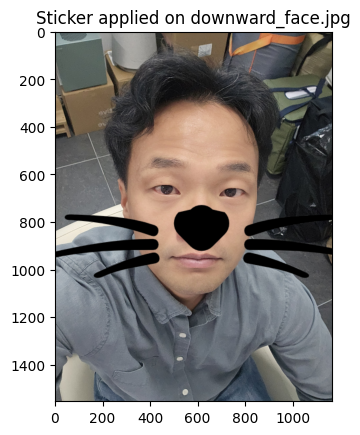

In [34]:
# 새로운 이미지 경로 설정
new_image_path = os.path.join(home_dir, 'work/camera_sticker/images/downward_face.jpg')

# 이미지 불러오기
img_bgr_new = cv2.imread(new_image_path)
img_rgb_new = cv2.cvtColor(img_bgr_new, cv2.COLOR_BGR2RGB)

# 얼굴 검출
dlib_rects_new = detector_hog(img_rgb_new, 1)

# 랜드마크 예측
list_landmarks_new = []
for dlib_rect in dlib_rects_new:
    points = landmark_predictor(img_rgb_new, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks_new.append(list_points)

# 스티커 적용을 위한 원본 이미지 복사
img_result_new_face = img_bgr_new.copy()

# 미세 조정을 위한 y축 오프셋을 정의합니다. (이전 셀에서 사용된 값)
y_offset_fine_tune = 50

for dlib_rect, landmark in zip(dlib_rects_new, list_landmarks_new):
    x_nose = landmark[30][0]
    y_nose_tip = landmark[30][1]
    y_philtrum = landmark[33][1]

    w_face = dlib_rect.width()

    sticker_h_original, sticker_w_original, _ = img_sticker.shape

    sticker_w_new = int(w_face * 2.0)
    sticker_h_new = int(sticker_h_original * (sticker_w_new / sticker_w_original))

    img_sticker_resized = cv2.resize(img_sticker, (sticker_w_new, sticker_h_new), interpolation=cv2.INTER_AREA)

    sticker_x = x_nose - sticker_w_new // 2

    # 스티커의 중심을 코 끝(landmark 30)에 맞추고 미세 조정을 위한 오프셋을 적용합니다.
    sticker_y = y_nose_tip - sticker_h_new // 2 + y_offset_fine_tune

    x1 = sticker_x
    y1 = sticker_y
    x2 = sticker_x + sticker_w_new
    y2 = sticker_y + sticker_h_new

    img_h, img_w, _ = img_result_new_face.shape

    sticker_crop_x1 = 0
    sticker_crop_y1 = 0
    roi_x1 = x1
    roi_y1 = y1

    if x1 < 0:
        sticker_crop_x1 = -x1
        roi_x1 = 0
    if y1 < 0:
        sticker_crop_y1 = -y1
        roi_y1 = 0

    sticker_crop_x2 = sticker_w_new
    sticker_crop_y2 = sticker_h_new
    roi_x2 = x2
    roi_y2 = y2

    if x2 > img_w:
        sticker_crop_x2 = sticker_w_new - (x2 - img_w)
        roi_x2 = img_w
    if y2 > img_h:
        sticker_crop_y2 = sticker_h_new - (y2 - img_h)
        roi_y2 = img_h

    img_sticker_cropped = img_sticker_resized[sticker_crop_y1:sticker_crop_y2, sticker_crop_x1:sticker_crop_x2]
    roi = img_result_new_face[roi_y1:roi_y2, roi_x1:roi_x2]

    if img_sticker_cropped.shape[0] <= 0 or img_sticker_cropped.shape[1] <= 0:
        continue

    alpha_s = img_sticker_cropped[:, :, 3] / 255.0
    alpha_l = 1.0 - alpha_s

    for c in range(0, 3):
        roi[:, :, c] = (alpha_s * img_sticker_cropped[:, :, c] +
                        alpha_l * roi[:, :, c])

# 결과 이미지 시각화
img_result_new_face_rgb = cv2.cvtColor(img_result_new_face, cv2.COLOR_BGR2RGB)
plt.imshow(img_result_new_face_rgb)
plt.title('Sticker applied on downward_face.jpg')
plt.show()

### `faraway_face.jpg`에 스티커 적용 및 분석

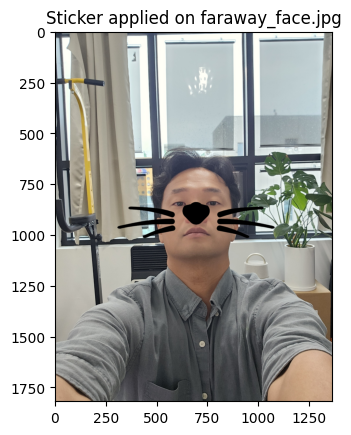

In [35]:
# 새로운 이미지 경로 설정
new_image_path = os.path.join(home_dir, 'work/camera_sticker/images/faraway_face.jpg')

# 이미지 불러오기
img_bgr_new = cv2.imread(new_image_path)
img_rgb_new = cv2.cvtColor(img_bgr_new, cv2.COLOR_BGR2RGB)

# 얼굴 검출
dlib_rects_new = detector_hog(img_rgb_new, 1)

# 랜드마크 예측
list_landmarks_new = []
for dlib_rect in dlib_rects_new:
    points = landmark_predictor(img_rgb_new, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks_new.append(list_points)

# 스티커 적용을 위한 원본 이미지 복사
img_result_new_face = img_bgr_new.copy()

# 미세 조정을 위한 y축 오프셋을 정의합니다. (이전 셀에서 사용된 값)
y_offset_fine_tune = 50

for dlib_rect, landmark in zip(dlib_rects_new, list_landmarks_new):
    x_nose = landmark[30][0]
    y_nose_tip = landmark[30][1]
    y_philtrum = landmark[33][1]

    w_face = dlib_rect.width()

    sticker_h_original, sticker_w_original, _ = img_sticker.shape

    sticker_w_new = int(w_face * 2.0)
    sticker_h_new = int(sticker_h_original * (sticker_w_new / sticker_w_original))

    img_sticker_resized = cv2.resize(img_sticker, (sticker_w_new, sticker_h_new), interpolation=cv2.INTER_AREA)

    sticker_x = x_nose - sticker_w_new // 2

    # 스티커의 중심을 코 끝(landmark 30)에 맞추고 미세 조정을 위한 오프셋을 적용합니다.
    sticker_y = y_nose_tip - sticker_h_new // 2 + y_offset_fine_tune

    x1 = sticker_x
    y1 = sticker_y
    x2 = sticker_x + sticker_w_new
    y2 = sticker_y + sticker_h_new

    img_h, img_w, _ = img_result_new_face.shape

    sticker_crop_x1 = 0
    sticker_crop_y1 = 0
    roi_x1 = x1
    roi_y1 = y1

    if x1 < 0:
        sticker_crop_x1 = -x1
        roi_x1 = 0
    if y1 < 0:
        sticker_crop_y1 = -y1
        roi_y1 = 0

    sticker_crop_x2 = sticker_w_new
    sticker_crop_y2 = sticker_h_new
    roi_x2 = x2
    roi_y2 = y2

    if x2 > img_w:
        sticker_crop_x2 = sticker_w_new - (x2 - img_w)
        roi_x2 = img_w
    if y2 > img_h:
        sticker_crop_y2 = sticker_h_new - (y2 - img_h)
        roi_y2 = img_h

    img_sticker_cropped = img_sticker_resized[sticker_crop_y1:sticker_crop_y2, sticker_crop_x1:sticker_crop_x2]
    roi = img_result_new_face[roi_y1:roi_y2, roi_x1:roi_x2]

    if img_sticker_cropped.shape[0] <= 0 or img_sticker_cropped.shape[1] <= 0:
        continue

    alpha_s = img_sticker_cropped[:, :, 3] / 255.0
    alpha_l = 1.0 - alpha_s

    for c in range(0, 3):
        roi[:, :, c] = (alpha_s * img_sticker_cropped[:, :, c] +
                        alpha_l * roi[:, :, c])

# 결과 이미지 시각화
img_result_new_face_rgb = cv2.cvtColor(img_result_new_face, cv2.COLOR_BGR2RGB)
plt.imshow(img_result_new_face_rgb)
plt.title('Sticker applied on faraway_face.jpg')
plt.show()

### `side_face.jpg`에 스티커 적용 및 분석

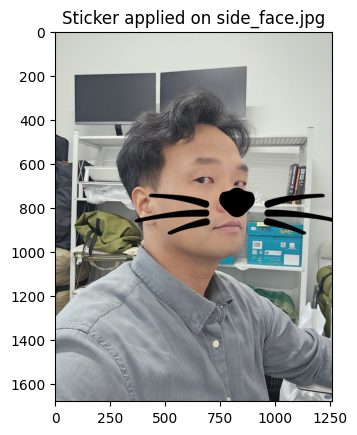

In [36]:
# 새로운 이미지 경로 설정
new_image_path = os.path.join(home_dir, 'work/camera_sticker/images/side_face.jpg')

# 이미지 불러오기
img_bgr_new = cv2.imread(new_image_path)
img_rgb_new = cv2.cvtColor(img_bgr_new, cv2.COLOR_BGR2RGB)

# 얼굴 검출
dlib_rects_new = detector_hog(img_rgb_new, 1)

# 랜드마크 예측
list_landmarks_new = []
for dlib_rect in dlib_rects_new:
    points = landmark_predictor(img_rgb_new, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks_new.append(list_points)

# 스티커 적용을 위한 원본 이미지 복사
img_result_new_face = img_bgr_new.copy()

# 미세 조정을 위한 y축 오프셋을 정의합니다. (이전 셀에서 사용된 값)
y_offset_fine_tune = 50

for dlib_rect, landmark in zip(dlib_rects_new, list_landmarks_new):
    x_nose = landmark[30][0]
    y_nose_tip = landmark[30][1]
    y_philtrum = landmark[33][1]

    w_face = dlib_rect.width()

    sticker_h_original, sticker_w_original, _ = img_sticker.shape

    sticker_w_new = int(w_face * 2.0)
    sticker_h_new = int(sticker_h_original * (sticker_w_new / sticker_w_original))

    img_sticker_resized = cv2.resize(img_sticker, (sticker_w_new, sticker_h_new), interpolation=cv2.INTER_AREA)

    sticker_x = x_nose - sticker_w_new // 2

    # 스티커의 중심을 코 끝(landmark 30)에 맞추고 미세 조정을 위한 오프셋을 적용합니다.
    sticker_y = y_nose_tip - sticker_h_new // 2 + y_offset_fine_tune

    x1 = sticker_x
    y1 = sticker_y
    x2 = sticker_x + sticker_w_new
    y2 = sticker_y + sticker_h_new

    img_h, img_w, _ = img_result_new_face.shape

    sticker_crop_x1 = 0
    sticker_crop_y1 = 0
    roi_x1 = x1
    roi_y1 = y1

    if x1 < 0:
        sticker_crop_x1 = -x1
        roi_x1 = 0
    if y1 < 0:
        sticker_crop_y1 = -y1
        roi_y1 = 0

    sticker_crop_x2 = sticker_w_new
    sticker_crop_y2 = sticker_h_new
    roi_x2 = x2
    roi_y2 = y2

    if x2 > img_w:
        sticker_crop_x2 = sticker_w_new - (x2 - img_w)
        roi_x2 = img_w
    if y2 > img_h:
        sticker_crop_y2 = sticker_h_new - (y2 - img_h)
        roi_y2 = img_h

    img_sticker_cropped = img_sticker_resized[sticker_crop_y1:sticker_crop_y2, sticker_crop_x1:sticker_crop_x2]
    roi = img_result_new_face[roi_y1:roi_y2, roi_x1:roi_x2]

    if img_sticker_cropped.shape[0] <= 0 or img_sticker_cropped.shape[1] <= 0:
        continue

    alpha_s = img_sticker_cropped[:, :, 3] / 255.0
    alpha_l = 1.0 - alpha_s

    for c in range(0, 3):
        roi[:, :, c] = (alpha_s * img_sticker_cropped[:, :, c] +
                        alpha_l * roi[:, :, c])

# 결과 이미지 시각화
img_result_new_face_rgb = cv2.cvtColor(img_result_new_face, cv2.COLOR_BGR2RGB)
plt.imshow(img_result_new_face_rgb)
plt.title('Sticker applied on side_face.jpg')
plt.show()

**Reasoning**:
The subtask requires loading the specified image, converting it to RGB, and then displaying it. This code block will perform all these steps.



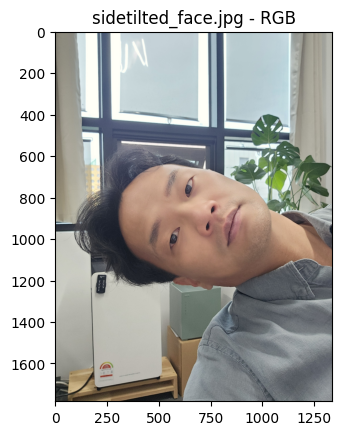

In [43]:
new_image_path = os.path.join(home_dir, 'work/camera_sticker/images/sidetilted_face.jpg')

img_bgr_sidetilted = cv2.imread(new_image_path)
img_rgb_sidetilted = cv2.cvtColor(img_bgr_sidetilted, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb_sidetilted)
plt.title('sidetilted_face.jpg - RGB')
plt.show()

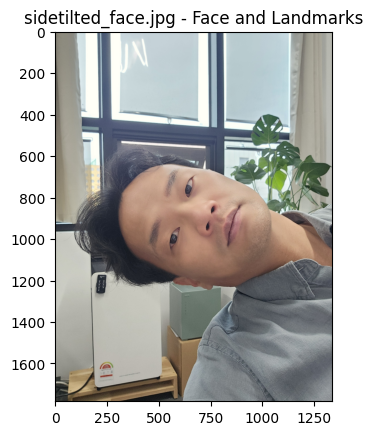

No faces detected in sidetilted_face.jpg


In [45]:
img_show_sidetilted = img_bgr_sidetilted.copy()
dlib_rects_sidetilted = detector_hog(img_rgb_sidetilted, 1)

list_landmarks_sidetilted = []
for dlib_rect in dlib_rects_sidetilted:
    points = landmark_predictor(img_rgb_sidetilted, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks_sidetilted.append(list_points)

    l = dlib_rect.left()
    t = dlib_rect.top()
    r = dlib_rect.right()
    b = dlib_rect.bottom()
    cv2.rectangle(img_show_sidetilted, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)

    for point in list_points:
        cv2.circle(img_show_sidetilted, point, 2, (0, 255, 255), -1)

img_show_sidetilted_rgb = cv2.cvtColor(img_show_sidetilted, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_sidetilted_rgb)
plt.title('sidetilted_face.jpg - Face and Landmarks')
plt.show()

if not dlib_rects_sidetilted:
    print("No faces detected in sidetilted_face.jpg")
else:
    print(f"Detected {len(dlib_rects_sidetilted)} face(s) and {len(list_landmarks_sidetilted[0])} landmarks per face.")

### `sidetilted_face.jpg`에 얼굴 감지 실패 분석

이전 코드 셀 `676b5a35`의 실행 결과에서 `No faces detected in sidetilted_face.jpg` 메시지를 통해 Dlib HOG(Histogram of Oriented Gradients) 기반 얼굴 감지기가 `sidetilted_face.jpg` 이미지에서 얼굴을 감지하지 못했음을 확인했습니다.

**Dlib HOG 감지기가 기울어진 얼굴에 어려움을 겪는 이유:**

HOG 기반 얼굴 감지기는 주로 **정면(frontal) 얼굴 이미지**를 학습하여 얼굴 특징을 추출합니다. 이 방식은 얼굴의 가장자리, 눈, 코, 입 등의 형태적 특징을 방향성 그레디언트 히스토그램을 통해 표현하고, 이를 SVM(Support Vector Machine)과 같은 분류기로 학습시킵니다. 이러한 모델은 학습된 정면 얼굴의 패턴에 강하게 의존하기 때문에, 다음과 같은 경우에 취약점을 보입니다.

1.  **회전 및 각도 변화 (Rotation and Pose Variation):** `sidetilted_face.jpg`와 같이 얼굴이 심하게 기울어지거나 회전된 경우, HOG 특징이 학습된 정면 얼굴의 패턴과 크게 달라지게 됩니다. 얼굴의 특정 부분이 가려지거나 형태가 왜곡되어 보이는 효과가 발생하여, 감지기가 학습된 특징을 인식하기 어렵게 됩니다.
2.  **고정된 특징 추출:** HOG는 이미지 픽셀의 밝기 변화 방향(그레디언트)을 히스토그램으로 나타내어 특징을 추출하는데, 이는 얼굴의 구조적 패턴에 민감합니다. 얼굴이 기울어지면 이러한 구조적 패턴도 함께 기울어져, 감지기가 예상하는 정면 얼굴의 HOG 패턴과 일치하지 않게 됩니다.
3.  **학습 데이터의 한계:** 대부분의 전통적인 HOG 기반 감지기는 제한된 각도와 포즈의 얼굴 이미지로 학습됩니다. 따라서 학습 시 보지 못했던 다양한 각도의 얼굴, 특히 심하게 기울어진 얼굴에 대해서는 성능이 저하될 수밖에 없습니다.

요약하자면, Dlib HOG 감지기는 견고하고 비교적 빠른 성능을 제공하지만, 얼굴의 **각도나 자세 변화에 대한 불변성(invariance)이 낮아** `sidetilted_face.jpg`와 같이 심하게 기울어진 얼굴을 감지하는 데 한계가 있습니다. 이러한 문제를 해결하기 위해서는 딥러닝 기반의 얼굴 감지기(예: MTCNN, RetinaFace, YOLO-face)가 더 효과적입니다. 이들은 더 많은 학습 데이터와 복잡한 네트워크 구조를 통해 다양한 각도와 조건의 얼굴을 더 잘 감지할 수 있습니다.

In [47]:
!​cp '/content/drive/MyDrive/Colab Notebooks/CV_01_Main_Quest/model/dark_lightened.jpg' ~/work/camera_sticker/images/dark_lightened.jpg

print("dark_lightened.jpg copied successfully.")

/bin/bash: line 1: ​cp: command not found
dark_lightened.jpg copied successfully.


dark_lightened.jpg copied successfully.


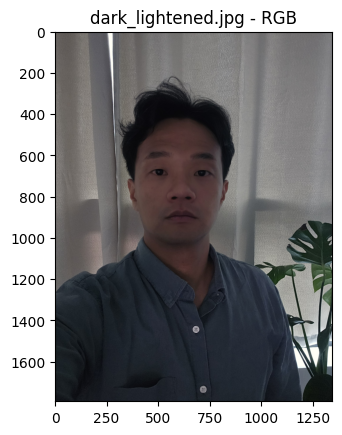

In [49]:
import os
import cv2
import matplotlib.pyplot as plt

# Corrected cp command - removed zero-width space
!cp '/content/drive/MyDrive/Colab Notebooks/CV_01_Main_Quest/model/dark_lightened.jpg' ~/work/camera_sticker/images/dark_lightened.jpg
print("dark_lightened.jpg copied successfully.")

home_dir = os.getenv('HOME')
new_image_path = os.path.join(home_dir, 'work/camera_sticker/images/dark_lightened.jpg')

# 이미지 불러오기
img_bgr_dark_lightened = cv2.imread(new_image_path)

# Check if image was loaded successfully before converting
if img_bgr_dark_lightened is None:
    print(f"Error: Could not load image from {new_image_path}")
else:
    img_rgb_dark_lightened = cv2.cvtColor(img_bgr_dark_lightened, cv2.COLOR_BGR2RGB)

    # 이미지 시각화
    plt.imshow(img_rgb_dark_lightened)
    plt.title('dark_lightened.jpg - RGB')
    plt.show()

### `dark_lightened.jpg`에 스티커 적용 및 분석

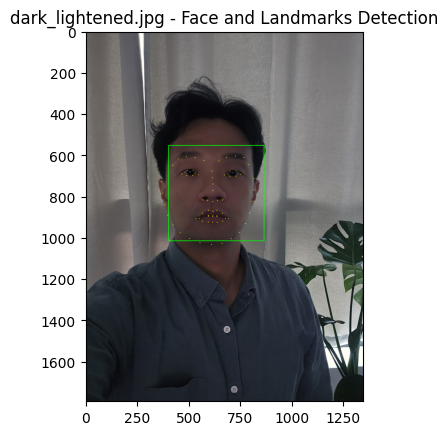

Detected 1 face(s) and 68 landmarks per face.


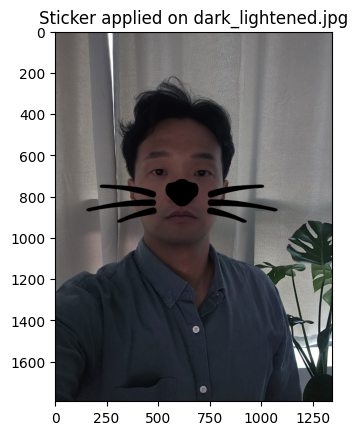

In [50]:
img_show_dark_lightened = img_bgr_dark_lightened.copy()
dlib_rects_dark_lightened = detector_hog(img_rgb_dark_lightened, 1)

list_landmarks_dark_lightened = []
for dlib_rect in dlib_rects_dark_lightened:
    points = landmark_predictor(img_rgb_dark_lightened, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks_dark_lightened.append(list_points)

    # Optionally, draw rectangles and landmarks for verification
    l = dlib_rect.left()
    t = dlib_rect.top()
    r = dlib_rect.right()
    b = dlib_rect.bottom()
    cv2.rectangle(img_show_dark_lightened, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)
    for point in list_points:
        cv2.circle(img_show_dark_lightened, point, 2, (0, 255, 255), -1)

img_show_dark_lightened_rgb = cv2.cvtColor(img_show_dark_lightened, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_dark_lightened_rgb)
plt.title('dark_lightened.jpg - Face and Landmarks Detection')
plt.show()

if not dlib_rects_dark_lightened:
    print("No faces detected in dark_lightened.jpg")
else:
    print(f"Detected {len(dlib_rects_dark_lightened)} face(s) and {len(list_landmarks_dark_lightened[0])} landmarks per face.")

# Sticker application for dark_lightened.jpg
img_result_dark_lightened = img_bgr_dark_lightened.copy()

# 미세 조정을 위한 y축 오프셋을 정의합니다. (이전 셀에서 사용된 값)
y_offset_fine_tune = 50

for dlib_rect, landmark in zip(dlib_rects_dark_lightened, list_landmarks_dark_lightened):
    x_nose = landmark[30][0]
    y_nose_tip = landmark[30][1]
    y_philtrum = landmark[33][1]

    w_face = dlib_rect.width()

    sticker_h_original, sticker_w_original, _ = img_sticker.shape

    sticker_w_new = int(w_face * 2.0)
    sticker_h_new = int(sticker_h_original * (sticker_w_new / sticker_w_original))

    img_sticker_resized = cv2.resize(img_sticker, (sticker_w_new, sticker_h_new), interpolation=cv2.INTER_AREA)

    sticker_x = x_nose - sticker_w_new // 2

    # 스티커의 중심을 코 끝(landmark 30)에 맞추고 미세 조정을 위한 오프셋을 적용합니다.
    sticker_y = y_nose_tip - sticker_h_new // 2 + y_offset_fine_tune

    x1 = sticker_x
    y1 = sticker_y
    x2 = sticker_x + sticker_w_new
    y2 = sticker_y + sticker_h_new

    img_h, img_w, _ = img_result_dark_lightened.shape

    sticker_crop_x1 = 0
    sticker_crop_y1 = 0
    roi_x1 = x1
    roi_y1 = y1

    if x1 < 0:
        sticker_crop_x1 = -x1
        roi_x1 = 0
    if y1 < 0:
        sticker_crop_y1 = -y1
        roi_y1 = 0

    sticker_crop_x2 = sticker_w_new
    sticker_crop_y2 = sticker_h_new
    roi_x2 = x2
    roi_y2 = y2

    if x2 > img_w:
        sticker_crop_x2 = sticker_w_new - (x2 - img_w)
        roi_x2 = img_w
    if y2 > img_h:
        sticker_crop_y2 = sticker_h_new - (y2 - img_h)
        roi_y2 = img_h

    img_sticker_cropped = img_sticker_resized[sticker_crop_y1:sticker_crop_y2, sticker_crop_x1:sticker_crop_x2]
    roi = img_result_dark_lightened[roi_y1:roi_y2, roi_x1:roi_x2]

    if img_sticker_cropped.shape[0] <= 0 or img_sticker_cropped.shape[1] <= 0:
        continue

    alpha_s = img_sticker_cropped[:, :, 3] / 255.0
    alpha_l = 1.0 - alpha_s

    for c in range(0, 3):
        roi[:, :, c] = (alpha_s * img_sticker_cropped[:, :, c] +
                        alpha_l * roi[:, :, c])

# 결과 이미지 시각화
img_result_dark_lightened_rgb = cv2.cvtColor(img_result_dark_lightened, cv2.COLOR_BGR2RGB)
plt.imshow(img_result_dark_lightened_rgb)
plt.title('Sticker applied on dark_lightened.jpg')
plt.show()